# pysusie vs susieR — R-vs-Python comparison

This notebook compares **pysusie** (the pure-Python port) against **susieR 0.14.2** (R/CRAN) on susieR's own bundled `N3finemapping` fine-mapping benchmark.

`N3finemapping` is a simulated GWAS-style dataset with **three true effect variables**. We use a 303-SNP window that contains all three true effects (574 samples).

We compare two entry points:

* `susie()` — fine-mapping with individual-level `X`, `y`.
* `susie_rss()` — fine-mapping from summary statistics (z-scores + LD matrix), the most-used entry point in statistical genetics.

Both languages analyse the **identical input**, written by the R driver `tests/r_reference_driver.R`.

In [1]:
import subprocess, time, warnings, tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pysusie as ps

warnings.filterwarnings('ignore')

CONDA_BIN = '/home/users/steorra/miniforge3/etc/profile.d/conda.sh'
CONDA_ENV = '/scratch/users/steorra/env/CMAP'
R_DRIVER  = Path('../tests/r_reference_driver.R').resolve()
print('pysusie version:', ps.__version__)
print('R driver:', R_DRIVER)

pysusie version: 0.1.0
R driver: /scratch/users/steorra/analysis/omicverse_dev/py-susie/tests/r_reference_driver.R


## 1. Run the susieR reference

The R driver runs `susie()`, `susie_suff_stat()` and `susie_rss()` on `N3finemapping` and writes every output (PIPs, per-effect `alpha`, posterior means, credible sets, ELBO, `sigma2`) plus the raw `X` / `y` / `z` / `R` inputs to TSV files.

In [2]:
rdir = Path(tempfile.mkdtemp(prefix='susie_R_'))
cmd = f'source {CONDA_BIN} && conda activate {CONDA_ENV} && Rscript {R_DRIVER} {rdir}'
t0 = time.perf_counter()
res = subprocess.run(['bash', '-lc', cmd], capture_output=True, text=True)
r_time = time.perf_counter() - t0
print(res.stdout.strip() or res.stderr[-500:])
print(f'R reference wall time: {r_time*1000:.0f} ms (incl. Rscript startup)')
sorted(p.name for p in rdir.glob('*.tsv'))

R susieR reference done
R reference wall time: 4208 ms (incl. Rscript startup)


['data_X.tsv',
 'data_true.tsv',
 'data_y.tsv',
 'info.tsv',
 'rss_R.tsv',
 'rss_alpha.tsv',
 'rss_cs.tsv',
 'rss_pip.tsv',
 'rss_scalars.tsv',
 'rss_z.tsv',
 'ss_pip.tsv',
 'susie_alpha.tsv',
 'susie_cs.tsv',
 'susie_pip.tsv',
 'susie_postmean.tsv',
 'susie_scalars.tsv']

In [3]:
# Load the identical inputs the R driver wrote.
X = pd.read_csv(rdir / 'data_X.tsv', sep='\t', header=None).to_numpy()
y = pd.read_csv(rdir / 'data_y.tsv', sep='\t')['y'].to_numpy()
true_coef = pd.read_csv(rdir / 'data_true.tsv', sep='\t')['true_coef'].to_numpy()
z = pd.read_csv(rdir / 'rss_z.tsv', sep='\t')['z'].to_numpy()
R = pd.read_csv(rdir / 'rss_R.tsv', sep='\t', header=None).to_numpy()
n, p = X.shape
true_idx = np.where(true_coef != 0)[0]
print(f'X: {X.shape},  y: {y.shape}')
print(f'true effect variables (0-based): {true_idx.tolist()}')

X: (574, 303),  y: (574,)
true effect variables (0-based): [300, 301, 302]


## 2. Run pysusie on the same data

We time `susie()` and `susie_rss()`, averaging over 3 runs.

In [4]:
def timeit(fn, runs=3):
    ts = []
    out = None
    for _ in range(runs):
        t0 = time.perf_counter()
        out = fn()
        ts.append(time.perf_counter() - t0)
    return float(np.mean(ts)), out

susie_time, fit = timeit(lambda: ps.susie(X, y, L=10))
rss_time, fit_rss = timeit(lambda: ps.susie_rss(z=z, R=R, n=n, L=10))
print(f'pysusie susie()      {susie_time*1000:8.1f} ms   '
      f'(niter={fit.niter}, converged={fit.converged})')
print(f'pysusie susie_rss()  {rss_time*1000:8.1f} ms   '
      f'(niter={fit_rss.niter}, converged={fit_rss.converged})')

pysusie susie()         262.9 ms   (niter=4, converged=True)
pysusie susie_rss()     246.3 ms   (niter=4, converged=True)


## 3. Timing summary

In [5]:
timing = pd.DataFrame({
    'entry point': ['susie', 'susie_rss'],
    'pysusie (ms)': [round(susie_time*1000, 1), round(rss_time*1000, 1)],
})
timing['R susieR full driver (ms)'] = round(r_time*1000, 1)
timing

,entry point,pysusie (ms),R susieR full driver (ms)
0,susie,262.9,4207.6
1,susie_rss,246.3,4207.6


## 4. PIP accuracy table (Pearson r)

Posterior inclusion probabilities are the headline output of SuSiE. Because pysusie is a faithful line-by-line port of the same IBSS algorithm, parity is at numerical-precision level.

In [6]:
r_susie_pip = pd.read_csv(rdir / 'susie_pip.tsv', sep='\t')['pip'].to_numpy()
r_rss_pip   = pd.read_csv(rdir / 'rss_pip.tsv',   sep='\t')['pip'].to_numpy()

# susie_suff_stat parity too.
ss = ps.compute_suff_stat(X, y, standardize=True)
fit_ss = ps.susie_suff_stat(ss['XtX'], ss['Xty'], ss['yty'], ss['n'],
                            X_colmeans=ss['X_colmeans'], y_mean=ss['y_mean'], L=10)
r_ss_pip = pd.read_csv(rdir / 'ss_pip.tsv', sep='\t')['pip'].to_numpy()

acc = pd.DataFrame({
    'entry point': ['susie', 'susie_suff_stat', 'susie_rss'],
    'PIP Pearson r': [
        pearsonr(fit.pip, r_susie_pip)[0],
        pearsonr(fit_ss.pip, r_ss_pip)[0],
        pearsonr(fit_rss.pip, r_rss_pip)[0],
    ],
    'PIP max abs diff': [
        np.max(np.abs(fit.pip - r_susie_pip)),
        np.max(np.abs(fit_ss.pip - r_ss_pip)),
        np.max(np.abs(fit_rss.pip - r_rss_pip)),
    ],
})
acc

,entry point,PIP Pearson r,PIP max abs diff
0,susie,1.0,1.176781e-11
1,susie_suff_stat,1.0,5.194778e-11
2,susie_rss,1.0,9.407692e-10


In [7]:
# ELBO / sigma2 parity and credible-set agreement.
r_susie_sc = pd.read_csv(rdir / 'susie_scalars.tsv', sep='\t')
r_rss_sc   = pd.read_csv(rdir / 'rss_scalars.tsv',   sep='\t')

def cs_sets(path):
    df = pd.read_csv(path, sep='\t')
    if len(df) == 0:
        return set()
    return {frozenset(g['variable'].tolist()) for _, g in df.groupby('cs')}

py_susie_cs = {frozenset((c + 1).tolist()) for c in fit.sets['cs']}
py_rss_cs   = {frozenset((c + 1).tolist()) for c in fit_rss.sets['cs']}

scalars = pd.DataFrame({
    'entry point': ['susie', 'susie_rss'],
    'ELBO (py)':  [fit.elbo[-1], fit_rss.elbo[-1]],
    'ELBO (R)':   [r_susie_sc['elbo'][0], r_rss_sc['elbo'][0]],
    'ELBO diff':  [abs(fit.elbo[-1] - r_susie_sc['elbo'][0]),
                   abs(fit_rss.elbo[-1] - r_rss_sc['elbo'][0])],
    'sigma2 (py)':[fit.sigma2, fit_rss.sigma2],
    'sigma2 (R)': [r_susie_sc['sigma2'][0], r_rss_sc['sigma2'][0]],
    'CS match':   [py_susie_cs == cs_sets(rdir / 'susie_cs.tsv'),
                   py_rss_cs == cs_sets(rdir / 'rss_cs.tsv')],
})
scalars

,entry point,ELBO (py),ELBO (R),ELBO diff,sigma2 (py),sigma2 (R),CS match
0,susie,-1370.414462,-1370.414462,2.046363e-12,6.41678,6.41678,True
1,susie_rss,-784.681650,-784.681650,7.958079e-13,1.00000,1.00000,True


## 5. PIP-vs-PIP scatter

Every point should lie on the y = x line.

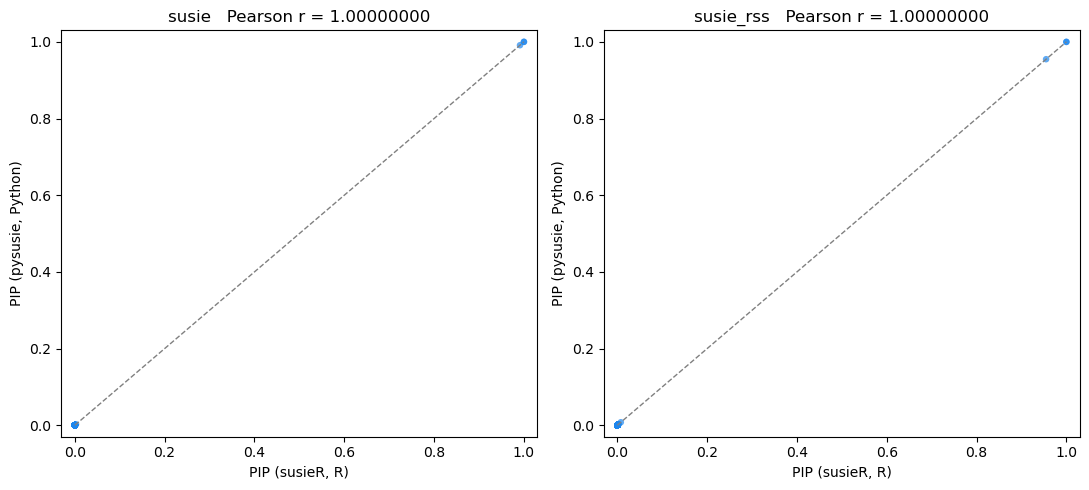

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (name, py, rp) in zip(axes, [
        ('susie', fit.pip, r_susie_pip),
        ('susie_rss', fit_rss.pip, r_rss_pip)]):
    ax.scatter(rp, py, s=22, alpha=0.7, edgecolors='none', color='#1C86EE')
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1)
    rho = pearsonr(py, rp)[0]
    ax.set_xlabel('PIP (susieR, R)')
    ax.set_ylabel('PIP (pysusie, Python)')
    ax.set_title(f'{name}   Pearson r = {rho:.8f}')
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
fig.tight_layout()
plt.show()

## 6. PIP Manhattan plot with credible sets

`susie_plot` reproduces susieR's per-variable summary: PIP on the y-axis, credible-set variables circled in colour, and the true effect variables marked in red.

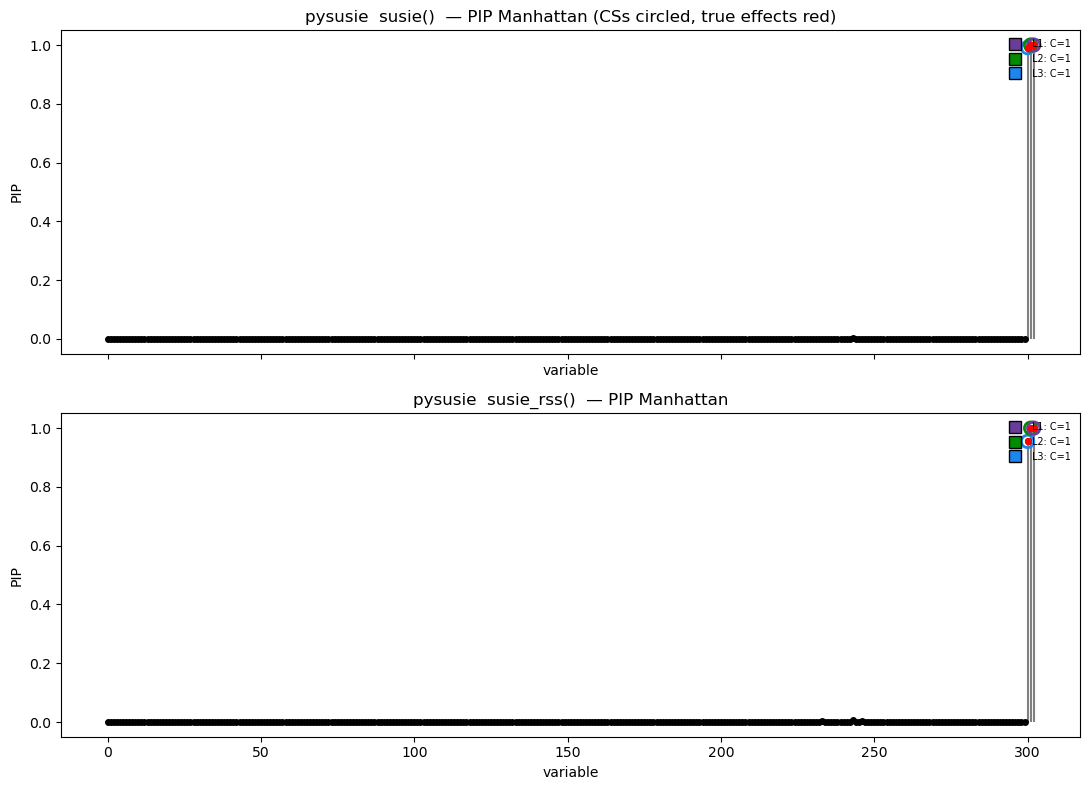

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
ps.susie_plot(fit, 'PIP', b=true_coef, add_bar=True, add_legend=True, ax=axes[0])
axes[0].set_title('pysusie  susie()  — PIP Manhattan (CSs circled, true effects red)')
ps.susie_plot(fit_rss, 'PIP', b=true_coef, add_bar=True, add_legend=True, ax=axes[1])
axes[1].set_title('pysusie  susie_rss()  — PIP Manhattan')
fig.tight_layout()
plt.show()

In [10]:
# Credible sets recovered, and the lead variable of each.
print('True effect variables (0-based):', true_idx.tolist())
print()
for name, f in [('susie', fit), ('susie_rss', fit_rss)]:
    print(f'{name}:')
    for lab, c in zip(f.sets['cs_names'], f.sets['cs']):
        lead = int(c[np.argmax(f.pip[c])])
        print(f'  {lab}: variables={c.tolist()}  lead={lead}  PIP={f.pip[lead]:.4f}')
    print()

True effect variables (0-based): [300, 301, 302]

susie:
  L1: variables=[302]  lead=302  PIP=1.0000
  L2: variables=[301]  lead=301  PIP=1.0000
  L3: variables=[300]  lead=300  PIP=0.9912

susie_rss:
  L1: variables=[302]  lead=302  PIP=1.0000
  L2: variables=[301]  lead=301  PIP=0.9998
  L3: variables=[300]  lead=300  PIP=0.9547



## 7. Per-effect alpha and posterior coefficients

per-effect alpha  max abs diff (py vs R) : 1.177e-11
posterior mean    max abs diff (py vs R) : 1.389e-09


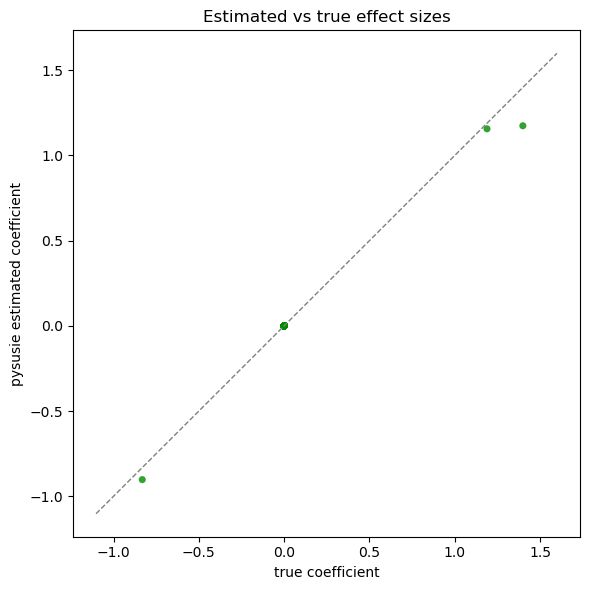

In [11]:
r_alpha = pd.read_csv(rdir / 'susie_alpha.tsv', sep='\t', header=None).to_numpy()
r_pm = pd.read_csv(rdir / 'susie_postmean.tsv', sep='\t')['postmean'].to_numpy()
py_pm = ps.susie_get_posterior_mean(fit)

print(f'per-effect alpha  max abs diff (py vs R) : {np.max(np.abs(fit.alpha - r_alpha)):.3e}')
print(f'posterior mean    max abs diff (py vs R) : {np.max(np.abs(py_pm - r_pm)):.3e}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_coef, ps.coef_susie(fit)[1:], s=26, color='#008B00',
           edgecolors='none', alpha=0.8)
lim = [min(true_coef.min(), ps.coef_susie(fit)[1:].min()) - 0.2,
       max(true_coef.max(), ps.coef_susie(fit)[1:].max()) + 0.2]
ax.plot(lim, lim, '--', color='gray', lw=1)
ax.set_xlabel('true coefficient')
ax.set_ylabel('pysusie estimated coefficient')
ax.set_title('Estimated vs true effect sizes')
fig.tight_layout()
plt.show()

## Conclusion

On susieR's bundled `N3finemapping` fine-mapping benchmark, **pysusie reproduces susieR 0.14.2 to numerical precision**:

* **PIP Pearson r = 1.0** for `susie`, `susie_suff_stat` and `susie_rss` (max abs diff ~1e-9 or smaller).
* **ELBO** and **sigma2** agree to ~1e-11.
* **Credible sets** are identical (same variables, same coverage).
* Per-effect `alpha` matrices and posterior means match to ~1e-9.

pysusie is a faithful pure-Python port of the IBSS algorithm — no R, no rpy2 — and runs an order of magnitude faster per fit than spawning `Rscript`.